In [1]:
import pandas as pd
import trxtools.methods as ttm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Load data

Load count tables

In [2]:
# Use files with multioverlap disabled (no -O option)

df00_uniq = pd.read_csv("../03a_FeatureCounts_umitools/featureCounts_umitools_uniq.list", sep="\t", skiprows=1)
df00_uniq = df00_uniq.drop(columns=['Chr', 'Start', 'End', 'Strand']).set_index('Geneid')
df00_uniq = ttm.cleanNames(df00_uniq, ['02c_alignment_all_umitools/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
df00_uniq = df00_uniq[['none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2', 'Length']]

df01_multi = pd.read_csv("../03a_FeatureCounts_umitools/featureCounts_umitools_multimappers.list", sep="\t", skiprows=1)
df01_multi = df01_multi.drop(columns=['Chr', 'Start', 'End', 'Strand']).set_index('Geneid')
df01_multi = ttm.cleanNames(df01_multi, ['02c_alignment_all_umitools/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
df01_multi = df01_multi[['none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2', 'Length']]

Load TPM tables

In [3]:
df00_uniq_tpm = pd.read_csv("../03a_FeatureCounts_umitools/featureCounts_umitools_uniq_TPM.txt", sep="\t")
df00_uniq_tpm = ttm.cleanNames(df00_uniq_tpm, ['02c_alignment_all_umitools/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
df00_uniq_tpm = df00_uniq_tpm[['Geneid', 'none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2']].set_index('Geneid')

df01_multi_tpm = pd.read_csv("../03a_FeatureCounts_umitools/featureCounts_umitools_multimappers_TPM.txt", sep="\t")
df01_multi_tpm = ttm.cleanNames(df01_multi_tpm, ['02c_alignment_all_umitools/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
df01_multi_tpm = df01_multi_tpm[['Geneid', 'none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2']].set_index('Geneid')

## Basic QC

### Number of mapped reads

In [4]:
summary_uniq_new = pd.read_csv("../03a_FeatureCounts_umitools/featureCounts_umitools_uniq.list.summary", sep="\t")
summary_uniq_new = ttm.cleanNames(summary_uniq_new, ['02c_alignment_all_umitools/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
summary_uniq_new = summary_uniq_new[['Status', 'none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2']]

summary_multi_new = pd.read_csv("../03a_FeatureCounts_umitools/featureCounts_umitools_multimappers.list.summary", sep="\t")
summary_multi_new = ttm.cleanNames(summary_multi_new, ['02c_alignment_all_umitools/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
summary_multi_new = summary_multi_new[['Status', 'none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2']]

In [5]:
summary_uniq_new.sum(numeric_only=True)

none1           2416
none2          14029
Cyclon1       396457
Cyclon2       286930
Cyclon-CT1    119739
Cyclon-CT2    311067
Cyclon-NT1    226177
Cyclon-NT2    312913
dtype: int64

/tmp/ipykernel_9126/78272384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pd.DataFrame(summary_uniq_new.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])


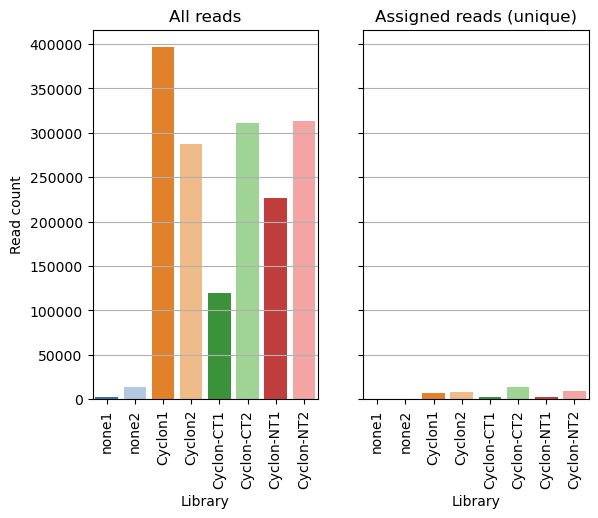

In [6]:
fig, axes = plt.subplots(1,2, sharey=True)
sns.barplot(pd.DataFrame(summary_uniq_new.sum()).T, palette='tab20', ax=axes[0])
sns.barplot(pd.DataFrame(summary_uniq_new.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])
plt.title("Read count per library")
axes[0].set_ylabel("Read count")
axes[0].set_title("All reads")
axes[1].set_title("Assigned reads (unique)")
for ax in axes:
    ax.grid(axis='y')
    ax.set_xlabel("Library")
    ax.tick_params(axis='x', rotation=90)
plt.savefig("00_qc_readcounts_unique.png", bbox_inches='tight', dpi=300)

/tmp/ipykernel_9126/3236030978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pd.DataFrame(summary_multi_new.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])


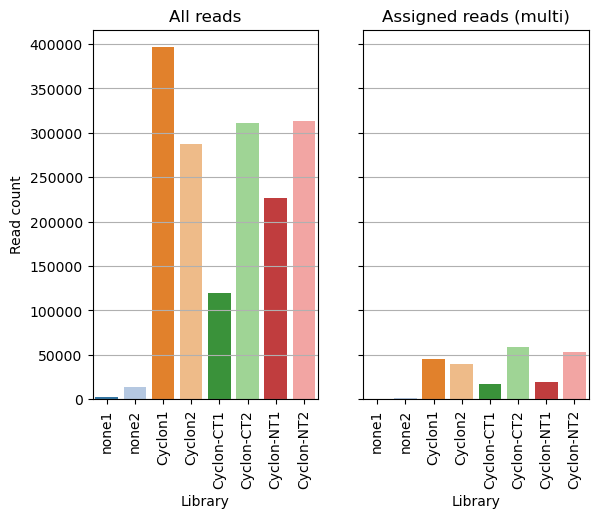

In [7]:
fig, axes = plt.subplots(1,2, sharey=True)
sns.barplot(pd.DataFrame(summary_multi_new.sum()).T, palette='tab20', ax=axes[0])
sns.barplot(pd.DataFrame(summary_multi_new.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])
# plt.title("Read count per library")
axes[0].set_ylabel("Read count")
axes[0].set_title("All reads")
axes[1].set_title("Assigned reads (multi)")
for ax in axes:
    ax.grid(axis='y')
    ax.set_xlabel("Library")
    ax.tick_params(axis='x', rotation=90)
plt.savefig("00_qc_readcounts_multi.png", bbox_inches='tight', dpi=300)

### Sample correlations

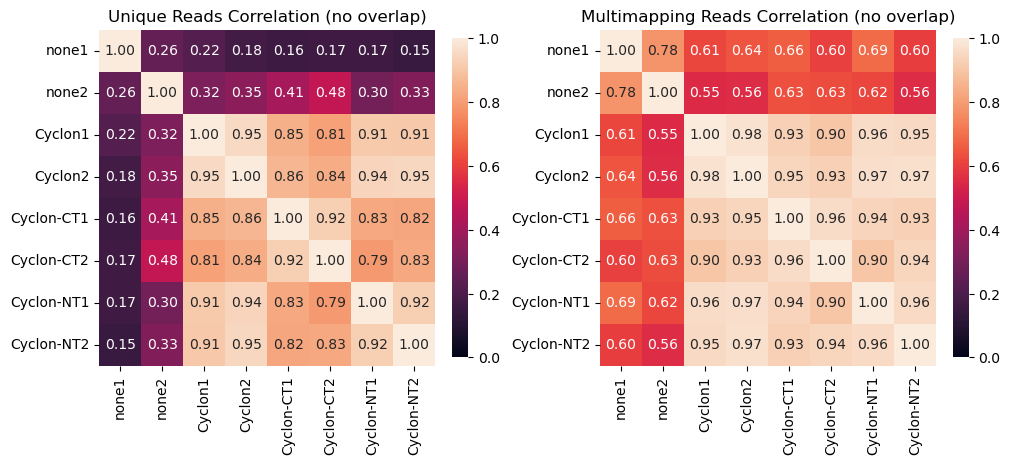

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

sns.heatmap(df00_uniq_tpm.corr('pearson', numeric_only=True), annot=True, fmt=".2f", square=True, vmin=0, vmax=1, cbar_kws={"shrink": .7}, ax=axes[0])
axes[0].set_title("Unique Reads Correlation (no overlap)")

sns.heatmap(df01_multi_tpm.corr('pearson', numeric_only=True), annot=True, fmt=".2f", square=True, vmin=0, vmax=1, cbar_kws={"shrink": .7}, ax=axes[1])
axes[1].set_title("Multimapping Reads Correlation (no overlap)")
plt.savefig("00_qc_correlation_heatmaps.png", dpi=300)

## Read classes
Look at what kinds of loci reads map to

Get gene types from GTF file

In [9]:
gtf = pd.read_csv("hg41_annotation_gencode_tRNA_rRNA.gtf", sep="\t", header=None)
gtf = gtf[gtf[2].isin(['gene'])]
gtf_classes = gtf[8].str.split("; ", expand=True)[[0,1]]
gtf_classes[0] = gtf_classes[0].str.replace('gene_id "', '', regex=False)
gtf_classes[0] = gtf_classes[0].str.replace('"', '', regex=False)
gtf_classes[1] = gtf_classes[1].str.replace('gene_type "', '', regex=False)
gtf_classes[1] = gtf_classes[1].str.replace('"', '', regex=False)
gtf_classes = gtf_classes.rename(columns={0: 'gene_id', 1: 'gene_type'})
gtf_classes = gtf_classes.set_index('gene_id')
gtf_classes.head()

,gene_type
gene_id,
ENSG00000223972.5,transcribed_unprocessed_pseudogene
ENSG00000227232.5,unprocessed_pseudogene
ENSG00000278267.1,miRNA
ENSG00000243485.5,lncRNA
ENSG00000284332.1,miRNA


In [10]:
df00_uniq = pd.concat([df00_uniq, gtf_classes], axis=1)
df01_multi = pd.concat([df01_multi, gtf_classes], axis=1)

df00_uniq_tpm = pd.concat([df00_uniq_tpm, gtf_classes], axis=1)
df01_multi_tpm = pd.concat([df01_multi_tpm, gtf_classes], axis=1)

In [11]:
df00_uniq.to_csv("00_allsamples_featureCounts_TPM_geneclasses_unique.csv")
df01_multi.to_csv("00_allsamples_featureCounts_TPM_geneclasses_multimapping.csv")

Prepare df for plotting

In [12]:
# Calculate percentages for barplot
bar_uniq = df00_uniq.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1) # type: ignore
bar_multi = df01_multi.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1)

bar_uniq_tpm = df00_uniq_tpm.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1)
bar_multi_tpm = df01_multi_tpm.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1)

#filter out some classes and sum them into 'other'
keep = [
    'Mt_rRNA', 'Mt_tRNA', 'lncRNA', 'miRNA',
    'polymorphic_pseudogene',
    'protein_coding', 'rRNA', 'rRNA_pseudogene',
    'snRNA', 'snoRNA', 'tRNA'
]

bar_uniq_keep = bar_uniq.loc[:,bar_uniq.columns.isin(keep)]
bar_uniq_keep['rRNA'] = bar_uniq_keep['rRNA'] + bar_uniq_keep['rRNA_pseudogene']
bar_uniq_keep = bar_uniq_keep.drop(columns=['rRNA_pseudogene'])
bar_uniq_plot = pd.concat([bar_uniq_keep, pd.DataFrame(bar_uniq.loc[:,~bar_uniq.columns.isin(keep)].sum(axis=1))], axis=1)
bar_uniq_plot = bar_uniq_plot.rename({0: 'other'}, axis=1)

bar_multi_keep = bar_multi.loc[:,bar_multi.columns.isin(keep)]
bar_multi_keep['rRNA'] = bar_multi_keep['rRNA'] + bar_multi_keep['rRNA_pseudogene']
bar_multi_keep = bar_multi_keep.drop(columns=['rRNA_pseudogene'])
bar_multi_plot = pd.concat([bar_multi_keep, pd.DataFrame(bar_multi.loc[:,~bar_multi.columns.isin(keep)].sum(axis=1))], axis=1)
bar_multi_plot = bar_multi_plot.rename({0: 'other'}, axis=1)

bar_uniq_tpm_keep = bar_uniq_tpm.loc[:,bar_uniq_tpm.columns.isin(keep)]
bar_uniq_tpm_keep['rRNA'] = bar_uniq_tpm_keep['rRNA'] + bar_uniq_tpm_keep['rRNA_pseudogene']
bar_uniq_tpm_keep = bar_uniq_tpm_keep.drop(columns=['rRNA_pseudogene'])
bar_uniq_tpm_plot = pd.concat([bar_uniq_tpm_keep, pd.DataFrame(bar_uniq_tpm.loc[:,~bar_uniq_tpm.columns.isin(keep)].sum(axis=1))], axis=1)
bar_uniq_tpm_plot = bar_uniq_tpm_plot.rename({0: 'other'}, axis=1)

bar_multi_tpm_keep = bar_multi_tpm.loc[:,bar_multi_tpm.columns.isin(keep)]
bar_multi_tpm_keep['rRNA'] = bar_multi_tpm_keep['rRNA'] + bar_multi_tpm_keep['rRNA_pseudogene']
bar_multi_tpm_keep = bar_multi_tpm_keep.drop(columns=['rRNA_pseudogene'])
bar_multi_tpm_plot = pd.concat([bar_multi_tpm_keep, pd.DataFrame(bar_multi_tpm.loc[:,~bar_multi_tpm.columns.isin(keep)].sum(axis=1))], axis=1)
bar_multi_tpm_plot = bar_multi_tpm_plot.rename({0: 'other'}, axis=1)

/tmp/ipykernel_9126/1688068574.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_uniq_keep['rRNA'] = bar_uniq_keep['rRNA'] + bar_uniq_keep['rRNA_pseudogene']
/tmp/ipykernel_9126/1688068574.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_multi_keep['rRNA'] = bar_multi_keep['rRNA'] + bar_multi_keep['rRNA_pseudogene']
/tmp/ipykernel_9126/1688068574.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

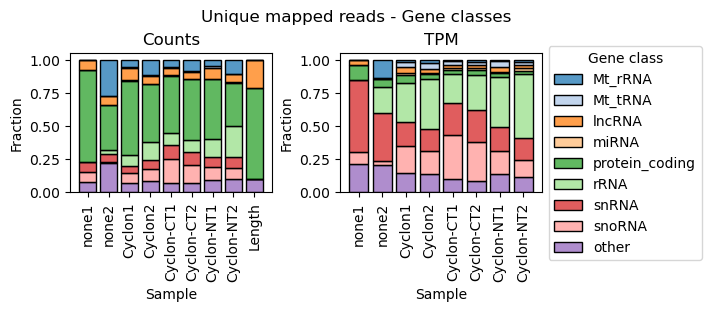

In [13]:
fig, axes = plt.subplots(1,2, figsize=(7, 3), layout='constrained')
sns.histplot(bar_uniq_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[0])
sns.histplot(bar_uniq_tpm_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[1])
axes[0].get_legend().remove()
legend = axes[1].get_legend()
legend.set_bbox_to_anchor((1, 1.1))
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('Fraction')
    ax.set_xlabel('Sample')
axes[0].set_title("Counts")
axes[1].set_title("TPM")
plt.suptitle("Unique mapped reads - Gene classes")
plt.savefig('00_read_classes_unique_comparison.png', dpi=300, bbox_inches='tight')

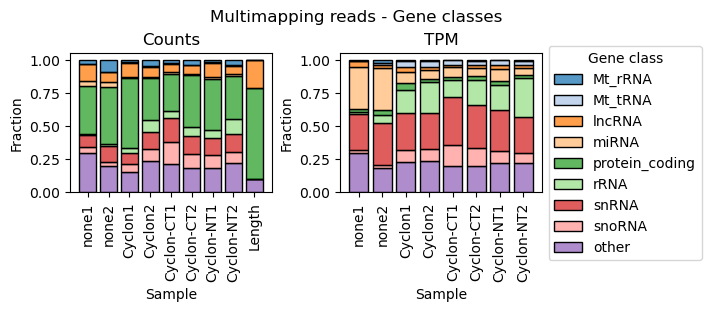

In [14]:
fig, axes = plt.subplots(1,2, figsize=(7, 3), layout='constrained')
sns.histplot(bar_multi_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[0])
sns.histplot(bar_multi_tpm_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[1])
axes[0].get_legend().remove()
legend = axes[1].get_legend()
legend.set_bbox_to_anchor((1, 1.1))
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('Fraction')
    ax.set_xlabel('Sample')
axes[0].set_title("Counts")
axes[1].set_title("TPM")
plt.suptitle("Multimapping reads - Gene classes")
plt.savefig('00_read_classes_multi_comparison.png', dpi=300, bbox_inches='tight')

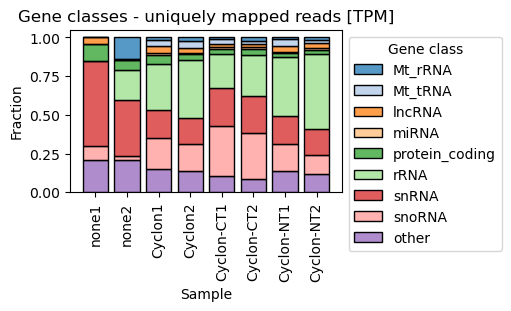

In [15]:
fig, ax = plt.subplots(figsize=(5, 3), layout='constrained')
sns.histplot(bar_uniq_tpm_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - uniquely mapped reads [TPM]")
plt.savefig('00_read_classes_unique_TPMonly.png', dpi=300, bbox_inches='tight')

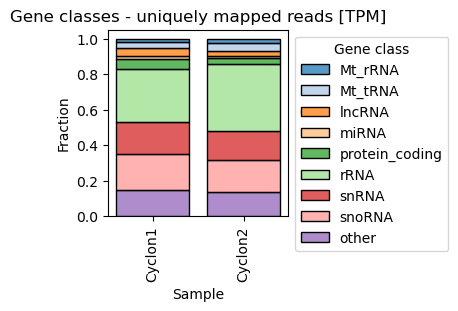

In [16]:
fig, ax = plt.subplots(figsize=(4, 3), layout='constrained')
sns.histplot(bar_uniq_tpm_plot.T[['Cyclon1', 'Cyclon2']].T.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - uniquely mapped reads [TPM]")
plt.savefig('00_read_classes_unique_TPMonly_simple.png', dpi=300, bbox_inches='tight')

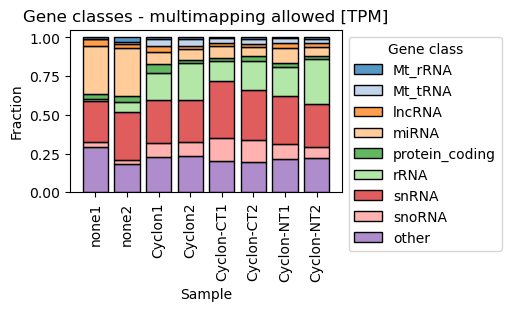

In [17]:
fig, ax = plt.subplots(figsize=(5, 3), layout='constrained')
sns.histplot(bar_multi_tpm_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - multimapping allowed [TPM]")
plt.savefig('00_read_classes_multi_TPMonly.png', dpi=300, bbox_inches='tight')

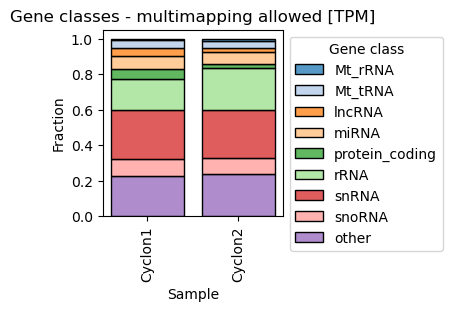

In [18]:
fig, ax = plt.subplots(figsize=(4, 3), layout='constrained')
sns.histplot(bar_multi_tpm_plot.T[['Cyclon1', 'Cyclon2']].T.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - multimapping allowed [TPM]")
plt.savefig('00_read_classes_multi_TPMonly_simple.png', dpi=300, bbox_inches='tight')

### Percent values of classes

In [19]:
bar_multi_tpm_plot

,Mt_rRNA,Mt_tRNA,lncRNA,miRNA,protein_coding,rRNA,snRNA,snoRNA,other
none1,0.012971,0.000000,0.040739,0.314990,0.028781,0.014411,0.266260,0.028446,0.293402
none2,0.029046,0.012323,0.025229,0.313364,0.036422,0.062569,0.315724,0.021688,0.183636
Cyclon1,0.008483,0.044779,0.042690,0.077964,0.055743,0.173734,0.277002,0.091963,0.227642
Cyclon2,0.011217,0.041866,0.021584,0.068328,0.022903,0.237623,0.270906,0.088554,0.237019
Cyclon-CT1,0.006411,0.031054,0.020175,0.076041,0.018712,0.128190,0.366117,0.152372,0.200927
Cyclon-CT2,0.009937,0.031117,0.022976,0.057410,0.031551,0.187066,0.325769,0.140118,0.194057
Cyclon-NT1,0.005387,0.032972,0.031302,0.093806,0.028644,0.189566,0.309761,0.091616,0.216948
Cyclon-NT2,0.008606,0.030001,0.020999,0.057957,0.022831,0.290171,0.274208,0.073148,0.222078


### Top hits in selected classes

#### snRNA

In [20]:
df_top_snrna = df01_multi_tpm[df01_multi_tpm['gene_type'] == 'snRNA'].copy()
df_top_snrna['Cyclon_mean'] = df_top_snrna[['Cyclon1', 'Cyclon2']].mean(axis=1)
df_top_snrna = df_top_snrna.sort_values('Cyclon_mean', ascending=False)
# df_top_snrna.columns = df_top_snrna.columns[-1:].tolist() + df_top_snrna.columns[:-1].tolist()
df_top_snrna.head(15)

,none1,none2,Cyclon1,Cyclon2,Cyclon-CT1,Cyclon-CT2,Cyclon-NT1,Cyclon-NT2,gene_type,Cyclon_mean
ENSG00000273768.1,5366.454317,19849.338651,6692.651442,7388.433963,12312.403306,11703.364737,8739.563330,8564.687090,snRNA,7040.542703
ENSG00000207005.1,5366.454317,21834.272516,6692.651442,7359.796622,12381.574111,11703.364737,8870.004573,8700.995107,snRNA,7026.224032
ENSG00000206737.1,5366.454317,19849.338651,6692.651442,7331.159282,12243.232501,11495.766250,8804.783951,8564.687090,snRNA,7011.905362
ENSG00000206652.1,5366.454317,19849.338651,6692.651442,7331.159282,12450.744916,11729.314548,8870.004573,8723.713110,snRNA,7011.905362
ENSG00000207513.1,5366.454317,19849.338651,6553.221203,7245.247259,12381.574111,11625.515304,8935.225195,8632.841098,snRNA,6899.234231
ENSG00000207389.1,5366.454317,21834.272516,6553.221203,7187.972577,12312.403306,11391.967006,8870.004573,8587.405093,snRNA,6870.596890
ENSG00000206596.1,5366.454317,19849.338651,6413.790965,7302.521941,12312.403306,11573.615682,8870.004573,8360.225064,snRNA,6858.156453
ENSG00000206588.1,5366.454317,19849.338651,6413.790965,7302.521941,12312.403306,11547.665871,8870.004573,8382.943067,snRNA,6858.156453
ENSG00000277918.1,5366.454317,15879.470921,5263.491499,5469.732120,9476.400297,8693.186667,6652.503430,6133.860780,snRNA,5366.611809
ENSG00000206585.1,0.000000,7939.735460,3869.189115,4782.435938,6917.080509,7655.194229,4304.561043,5656.782720,snRNA,4325.812526


#### snoRNA

In [21]:
df_top_snorna = df00_uniq_tpm[df00_uniq_tpm['gene_type'] == 'snoRNA'].copy()
df_top_snorna['Cyclon_mean'] = df_top_snorna[['Cyclon1', 'Cyclon2']].mean(axis=1)
df_top_snorna = df_top_snorna.sort_values('Cyclon_mean', ascending=False)
# df_top_snorna.columns = df_top_snorna.columns[-1:].tolist() + df_top_snorna.columns[:-1].tolist()
df_top_snorna.head(5)

,none1,none2,Cyclon1,Cyclon2,Cyclon-CT1,Cyclon-CT2,Cyclon-NT1,Cyclon-NT2,gene_type,Cyclon_mean
ENSG00000200087.1,0.0,22642.120452,23884.902730,23694.263561,47579.239748,25950.810785,24020.037781,17351.099063,snoRNA,23789.583146
ENSG00000252213.1,0.0,0.000000,5590.083618,5917.564304,11658.056685,9982.429411,8688.098772,4513.027918,snoRNA,5753.823961
ENSG00000212607.1,0.0,0.000000,4649.351295,5490.764457,8962.846197,8499.338611,4007.705322,2580.564866,snoRNA,5070.057876
ENSG00000200959.1,0.0,0.000000,4161.763354,5521.823326,14231.913356,16975.999359,6186.979428,4419.006503,snoRNA,4841.793340
ENSG00000207523.1,0.0,0.000000,5118.193442,4542.885119,12947.830948,9635.156027,1973.719538,3438.850925,snoRNA,4830.539281


#### rRNA

In [22]:
tsdf = pd.concat([df00_uniq_tpm[df00_uniq_tpm['gene_type'] == 'rRNA_pseudogene'],
           df00_uniq_tpm[df00_uniq_tpm['gene_type'] == 'rRNA']])
tsdf['Cyclon_mean'] = tsdf[['Cyclon1', 'Cyclon2']].mean(axis=1)
tsdf = tsdf.sort_values('Cyclon_mean', ascending=False)
# tsdf = tsdf.drop(columns=['gene_type']).apply(lambda x: x/sum(x), axis=1)
tsdf

,none1,none2,Cyclon1,Cyclon2,Cyclon-CT1,Cyclon-CT2,Cyclon-NT1,Cyclon-NT2,gene_type,Cyclon_mean
ENSG00000201321.1,0.0,0.0,16257.790934,22968.928963,19075.547733,16241.323757,28676.983881,26569.740781,rRNA,19613.359948
ENSG00000201185.1,0.0,0.0,8731.035872,13539.579178,12497.772653,11651.384434,13235.531022,15540.791777,rRNA_pseudogene,11135.307525
ENSG00000199994.1,0.0,0.0,8598.564983,10587.950917,10019.267002,6554.433353,7700.137826,9863.222515,rRNA_pseudogene,9593.257950
ENSG00000252211.1,0.0,0.0,5732.376655,8516.395303,10645.471190,7394.745321,17500.313240,15749.339177,rRNA_pseudogene,7124.385979
ENSG00000201920.1,0.0,0.0,6361.866615,7797.911840,10241.657275,6479.040877,10631.031408,7247.996647,rRNA_pseudogene,7079.889227
...,...,...,...,...,...,...,...,...,...,...
ENSG00000251997.1,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,rRNA_pseudogene,0.000000
ENSG00000200527.1,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,160.367171,rRNA_pseudogene,0.000000
ENSG00000200872.1,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,rRNA_pseudogene,0.000000
ENSG00000202060.1,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,rRNA_pseudogene,0.000000
